# Dataset 6: Т-Банк: использование сервисов Города

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [7]:
df = pd.read_csv('city_clients.csv')

In [9]:
df.head()

,party_rk,gorod_client_flg,fuel_gmv,fuel_avg_price,fuel_n_orders,fuel_first_order_date,fuel_last_order_date,supermarket_gmv,supermarket_avg_price,supermarket_n_orders,...,kino_gmv,kino_transactions_cnt,arenda_avto_gmv,arenda_avto_transactions_cnt,knigi_gmv,knigi_transactions_cnt,zhivotnye_gmv,zhivotnye_transactions_cnt,turagentstva_gmv,turagentstva_transactions_cnt
0,1002611776,1,1499.06,749.530000,2.0,2023-05-22,2024-07-08,NaN,NaN,NaN,...,798.0,128.0,0.0,128.0,0.0,128.0,0.0,128.0,0.0,128.0
1,812910044,1,5600.68,1866.893333,3.0,2023-01-12,2024-03-30,NaN,NaN,NaN,...,0.0,92.0,0.0,92.0,0.0,92.0,0.0,92.0,0.0,92.0
2,379196768,1,32831.06,1492.320909,22.0,2023-08-12,2024-09-28,3775.76,1887.88,2.0,...,512.0,457.0,0.0,457.0,0.0,457.0,0.0,457.0,21680.0,457.0
3,695174271,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,292.0,0.0,292.0,0.0,292.0,0.0,292.0,0.0,292.0
4,843828836,1,NaN,NaN,NaN,NaN,NaN,1687.82,1687.82,1.0,...,0.0,528.0,0.0,528.0,0.0,528.0,0.0,528.0,0.0,528.0


In [11]:
# смотрим на данные
df.describe()

,party_rk,gorod_client_flg,fuel_gmv,fuel_avg_price,fuel_n_orders,supermarket_gmv,supermarket_avg_price,supermarket_n_orders,afisha_gmv,afisha_avg_price,...,kino_gmv,kino_transactions_cnt,arenda_avto_gmv,arenda_avto_transactions_cnt,knigi_gmv,knigi_transactions_cnt,zhivotnye_gmv,zhivotnye_transactions_cnt,turagentstva_gmv,turagentstva_transactions_cnt
count,1.000000e+06,1000000.0,3.739710e+05,373971.000000,373971.000000,1.057850e+05,105785.000000,105785.000000,103359.000000,103359.000000,...,983519.000000,983519.000000,9.835190e+05,983519.000000,9.835190e+05,983519.000000,9.835190e+05,983519.000000,9.835190e+05,983519.000000
mean,6.657591e+08,0.5,2.279358e+04,1702.038241,14.430293,1.048409e+04,1886.426710,6.050952,5975.527313,3016.960747,...,181.706634,209.961228,3.116869e+02,209.961228,2.102093e+02,209.961228,3.938231e+02,209.961228,3.900314e+03,209.961228
std,3.220606e+08,0.5,3.239326e+04,822.476137,20.107284,2.436341e+04,1385.987569,12.713711,9852.675529,3562.216163,...,845.036469,218.914151,4.992884e+03,218.914151,3.632981e+03,218.914151,3.757513e+03,218.914151,3.197710e+04,218.914151
min,2.600000e+01,0.0,5.100000e-01,0.510000,1.000000,8.000000e+00,8.000000,1.000000,11.000000,11.000000,...,0.000000,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000
25%,3.696874e+08,0.0,3.665320e+03,1110.895305,2.000000,1.579760e+03,962.607500,1.000000,1100.000000,840.000000,...,0.000000,43.000000,0.000000e+00,43.000000,0.000000e+00,43.000000,0.000000e+00,43.000000,0.000000e+00,43.000000
50%,7.056538e+08,0.5,1.204133e+04,1602.006667,8.000000,3.404880e+03,1537.333333,2.000000,2900.000000,1686.000000,...,0.000000,155.000000,0.000000e+00,155.000000,0.000000e+00,155.000000,0.000000e+00,155.000000,0.000000e+00,155.000000
75%,9.433293e+08,1.0,3.065374e+04,2127.330000,19.000000,8.869610e+03,2407.272500,5.000000,7000.000000,4000.000000,...,0.000000,313.000000,0.000000e+00,313.000000,0.000000e+00,313.000000,0.000000e+00,313.000000,0.000000e+00,313.000000
max,1.301080e+09,1.0,2.912661e+06,39288.000000,1346.000000,1.084905e+06,35804.540000,383.000000,454180.000000,105000.000000,...,362650.000000,29888.000000,1.156844e+06,29888.000000,1.790157e+06,29888.000000,1.576487e+06,29888.000000,4.755822e+06,29888.000000


In [13]:
# Ровно половина клиентов пользовались сервисами города
gorod_use = df.groupby('gorod_client_flg')['party_rk'].count().reset_index()
gorod_use

,gorod_client_flg,party_rk
0,0,500000
1,1,500000


In [15]:
frequency = df.groupby('party_rk').agg({'fuel_n_orders' : 'sum', 'supermarket_n_orders' : 'sum', 'afisha_n_orders' : 'sum'}).reset_index()

In [17]:
# по квартилям видно, что у большинства клиентов нет заказов в категориях
# поэтому отберем тех, у кого был хотя бы один заказ в одном из трех сервисов
frequency.describe()

,party_rk,fuel_n_orders,supermarket_n_orders,afisha_n_orders
count,1.000000e+06,1000000.000000,1000000.000000,1000000.000000
mean,6.657591e+08,5.396511,0.640100,0.212090
std,3.220606e+08,14.140306,4.534564,0.939663
min,2.600000e+01,0.000000,0.000000,0.000000
25%,3.696874e+08,0.000000,0.000000,0.000000
50%,7.056538e+08,0.000000,0.000000,0.000000
75%,9.433293e+08,4.000000,0.000000,0.000000
max,1.301080e+09,1346.000000,383.000000,101.000000


In [19]:
df = df[df['gorod_client_flg'] == 1]

In [21]:
# еще раз посмотрим на распределение значений уже только клиентов, использовавших сервис
frequency = df.groupby('party_rk').agg({'fuel_n_orders' : 'sum', 'supermarket_n_orders' : 'sum', 'afisha_n_orders' : 'sum'}).reset_index()
frequency.describe()

,party_rk,fuel_n_orders,supermarket_n_orders,afisha_n_orders
count,5.000000e+05,500000.000000,500000.000000,500000.000000
mean,5.941458e+08,10.793022,1.280200,0.424180
std,3.113687e+08,18.483834,6.348631,1.294593
min,2.910000e+02,0.000000,0.000000,0.000000
25%,3.109518e+08,0.000000,0.000000,0.000000
50%,6.111306e+08,4.000000,0.000000,0.000000
75%,8.563724e+08,14.000000,0.000000,0.000000
max,1.301032e+09,1346.000000,383.000000,101.000000


изменились средние значения: увеличились все три столбца 
* fuel_n_orders - 5.396511 стало 10.793022
* supermarket_n_orders - 0.640100 стало 1.280200
* afisha_n_orders - 0.212090 стало 0.424180

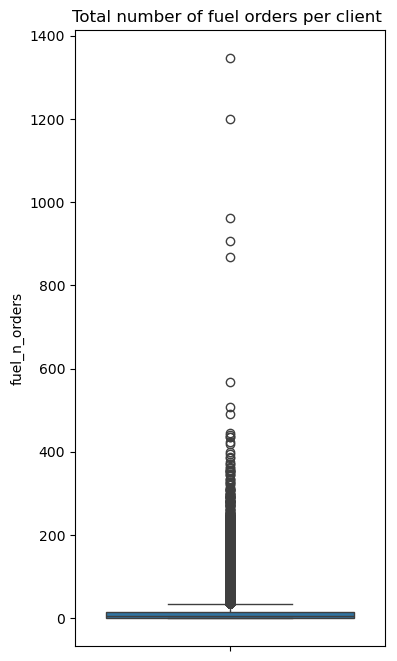

In [23]:
# провизуализируем распределение с помощью ящика с усами
# проверим гипотезу: есть маленькое количество клиентов с очень большим числом заказов в сервисе, 
# благодаря которым увеличивается средняя сумма по всем клиентам

plt.figure(figsize = (4,8))
plt.title('Total number of fuel orders per client ')
sns.boxplot(frequency['fuel_n_orders'])
plt.show()

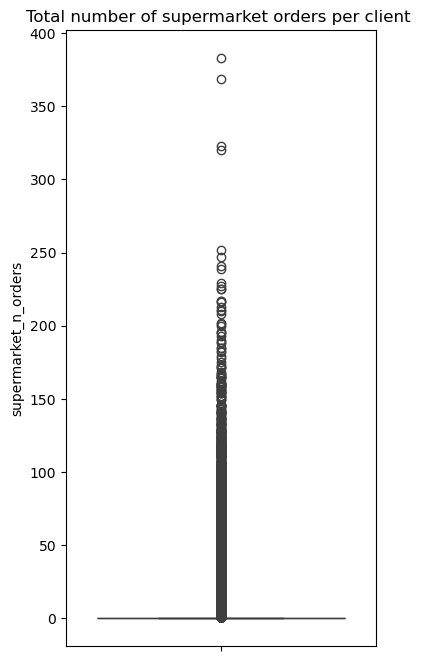

In [25]:
plt.figure(figsize = (4,8))
plt.title('Total number of supermarket orders per client ')
sns.boxplot(frequency['supermarket_n_orders'])
plt.show()

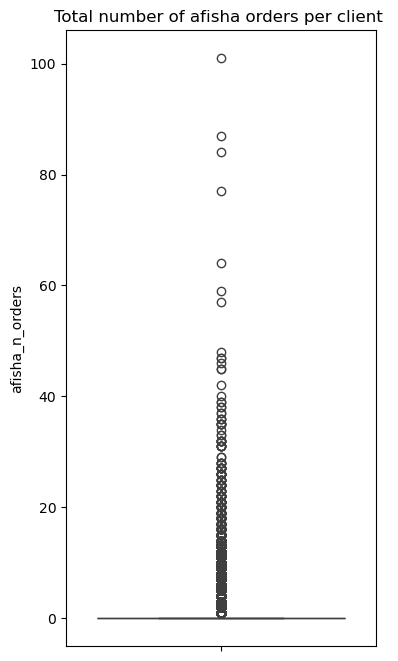

In [27]:
plt.figure(figsize = (4,8))
plt.title('Total number of afisha orders per client ')
sns.boxplot(frequency['afisha_n_orders'])
plt.show()

Гипотеза подтвердилась: от 25% до 75% квартиля у клиентов по 0 заказов

Кроме того, макс. количество использований "топлива" - почти 1400, а "афишей" - чуть больше 100

Это звучит логично, автомобилисты заправляются регулярнее, чем люди ходят в кино, театры

### Для упрощения анализа из всего датафрейма я выберу случайно 20_000 строк, где gorod_client_flg = 1

In [35]:
df_adjusted = df.sample(n = 20_000) # уже выше оставили в датасете только строки с флагом

In [37]:
df_adjusted.describe()

,party_rk,gorod_client_flg,fuel_gmv,fuel_avg_price,fuel_n_orders,supermarket_gmv,supermarket_avg_price,supermarket_n_orders,afisha_gmv,afisha_avg_price,...,kino_gmv,kino_transactions_cnt,arenda_avto_gmv,arenda_avto_transactions_cnt,knigi_gmv,knigi_transactions_cnt,zhivotnye_gmv,zhivotnye_transactions_cnt,turagentstva_gmv,turagentstva_transactions_cnt
count,2.000000e+04,20000.0,1.494800e+04,14948.000000,14948.000000,4206.000000,4206.000000,4206.000000,4054.000000,4054.000000,...,19654.000000,19654.000000,19654.000000,19654.000000,1.965400e+04,19654.000000,19654.000000,19654.000000,1.965400e+04,19654.000000
mean,5.990959e+08,1.0,2.325536e+04,1701.676960,14.661761,10630.678783,1880.808502,6.093438,5756.278984,2939.139487,...,273.546581,273.479648,433.759156,273.479648,3.695668e+02,273.479648,604.170884,273.479648,6.434047e+03,273.479648
std,3.132450e+08,0.0,3.303746e+04,819.539735,19.764422,23682.125153,1383.245229,12.675182,9505.225024,3821.209582,...,836.858432,218.056408,6695.350672,218.056408,1.291834e+04,218.056408,4966.596388,218.056408,3.979040e+04,218.056408
min,4.440000e+03,1.0,5.078000e+01,28.145000,1.000000,86.000000,43.000000,1.000000,22.000000,22.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000e+00,1.000000
25%,3.148460e+08,1.0,3.707540e+03,1108.126667,2.000000,1554.750000,975.894412,1.000000,1040.000000,800.000000,...,0.000000,110.000000,0.000000,110.000000,0.000000e+00,110.000000,0.000000,110.000000,0.000000e+00,110.000000
50%,6.177504e+08,1.0,1.244212e+04,1602.460714,8.000000,3337.355000,1548.191667,2.000000,2800.000000,1600.000000,...,0.000000,234.000000,0.000000,234.000000,0.000000e+00,234.000000,0.000000,234.000000,0.000000e+00,234.000000
75%,8.603460e+08,1.0,3.085642e+04,2121.536250,19.000000,9023.950000,2363.172857,5.000000,6600.000000,3920.000000,...,0.000000,384.000000,0.000000,384.000000,0.000000e+00,384.000000,0.000000,384.000000,0.000000e+00,384.000000
max,1.300559e+09,1.0,1.053760e+06,17933.333333,270.000000,410772.670000,17577.330000,165.000000,214860.000000,100000.000000,...,19200.000000,4929.000000,593954.930000,4929.000000,1.790157e+06,4929.000000,466697.760000,4929.000000,1.680002e+06,4929.000000


### Проанализирую только те столбцы, которые связаны с афишей. Список выбранных колонок:

* __party_rk__ - Идентификатор клиента
* __afisha_gmv__ - Оборот в сервисе «Афиша» с 01.01.2024
* __afisha_avg_price__ - Средняя сумма покупки в сервисе «Афиша»
* __afisha_n_orders__ - Количество заказов в сервисе «Афиша» с 01.01.2024
* __afisha_first_order_date__ - Дата первого заказа в сервисе «Афиша»
* __afisha_last_order_date__ - Дата последнего заказа в сервисе «Афиша»

In [261]:
# Оставляю только непустые строки
afisha = df_adjusted[['party_rk', 'afisha_gmv', 'afisha_avg_price', 'afisha_n_orders', 'afisha_first_order_date', 'afisha_last_order_date']].dropna()

In [263]:
afisha.head()

,party_rk,afisha_gmv,afisha_avg_price,afisha_n_orders,afisha_first_order_date,afisha_last_order_date
411073,598111362,5160.0,1290.0,4.0,2024-01-01,2024-05-26
161284,165409556,8190.0,1365.0,6.0,2019-07-06,2024-05-10
880610,380593416,4500.0,4500.0,1.0,2024-04-06,2024-04-06
621970,331569971,1020.0,1020.0,1.0,2021-01-03,2024-05-26
899139,610206965,4400.0,4400.0,1.0,2024-10-19,2024-10-19


In [265]:
# Количество пользователей, которые хотя бы раз пользовались сервисом "Афиша". Их поведение и буду анализировать
afisha['afisha_first_order_date'].count()

4054

In [267]:
afisha.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4054 entries, 411073 to 449277
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   party_rk                 4054 non-null   int64  
 1   afisha_gmv               4054 non-null   float64
 2   afisha_avg_price         4054 non-null   float64
 3   afisha_n_orders          4054 non-null   float64
 4   afisha_first_order_date  4054 non-null   object 
 5   afisha_last_order_date   4054 non-null   object 
dtypes: float64(3), int64(1), object(2)
memory usage: 221.7+ KB


In [269]:
# Преобразуем дату в подходящий тип данных
afisha['afisha_first_order_date'] = pd.to_datetime(afisha['afisha_first_order_date'])
afisha['afisha_last_order_date'] = pd.to_datetime(afisha['afisha_last_order_date'])

## Визуализация датафрейма

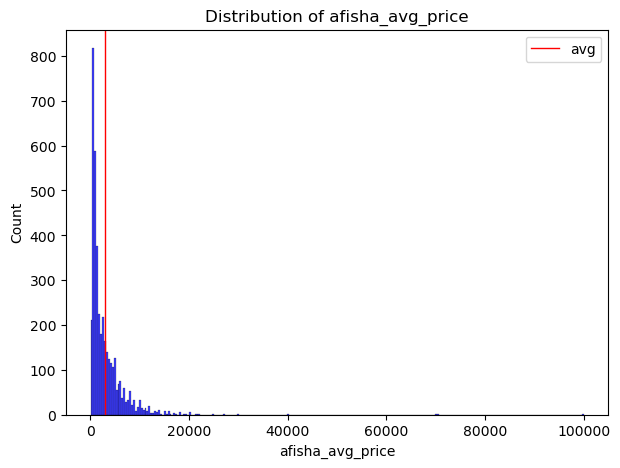

Mean value of average price: 2939.1394865115226
Median value of average price: 1600.0


In [271]:
plt.figure(figsize = (7, 5))
plt.title('Distribution of afisha_avg_price')
sns.histplot(afisha['afisha_avg_price'], color = 'b')
plt.axvline(afisha['afisha_avg_price'].mean(), color = 'r', linestyle = '-', linewidth = 1, label = 'avg')
plt.legend()
plt.show()

print('Mean value of average price:', afisha['afisha_avg_price'].mean())
print('Median value of average price:', afisha['afisha_avg_price'].median())

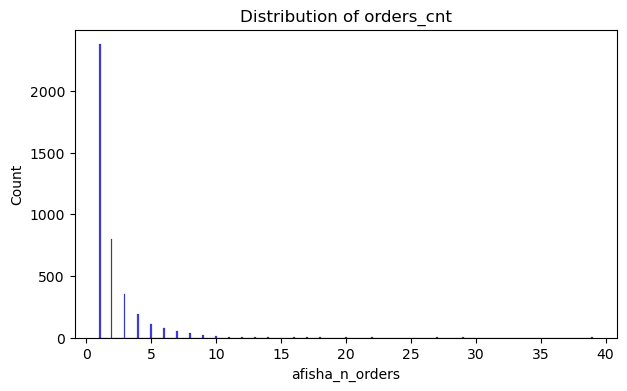

In [273]:
plt.figure(figsize=(7, 4))
sns.histplot(afisha['afisha_n_orders'], color = 'b')
plt.title('Distribution of orders_cnt')

plt.show()

### Нужно избавиться от выбросов, уберем строки со значениями > 30_000 в столбце afisha_avg_price

In [275]:
afisha = afisha[afisha['afisha_avg_price'] < 30_000]

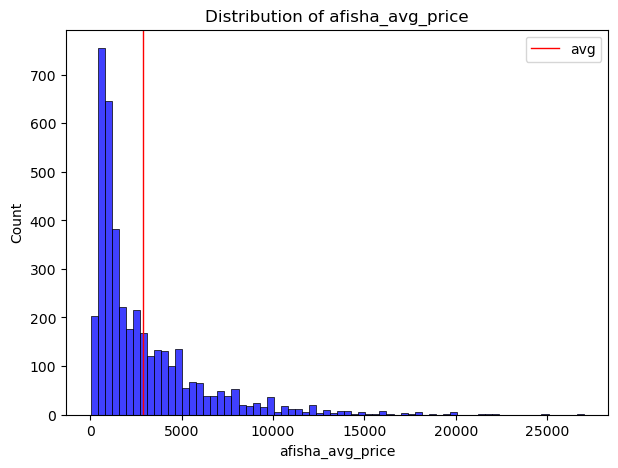

Mean value of average price: 2866.0611208490277
Median value of average price: 1600.0


In [277]:
plt.figure(figsize = (7, 5))
plt.title('Distribution of afisha_avg_price')
sns.histplot(afisha['afisha_avg_price'], color = 'b')
plt.axvline(afisha['afisha_avg_price'].mean(), color = 'r', linestyle = '-', linewidth = 1, label = 'avg')
plt.legend()
plt.show()

print('Mean value of average price:', afisha['afisha_avg_price'].mean())
print('Median value of average price:', afisha['afisha_avg_price'].median())

In [279]:
# Посмотрим, как изменялось количество использований сервиса по месяцам
# Группирую по месяцам и считаю сумму заказов

afisha['month'] = afisha['afisha_first_order_date'].dt.to_period('M').dt.to_timestamp()
orders_per_month = afisha.groupby('month')['afisha_n_orders'].sum().reset_index()

orders_per_month.tail()

,month,afisha_n_orders
66,2024-06-01,192.0
67,2024-07-01,180.0
68,2024-08-01,207.0
69,2024-09-01,194.0
70,2024-10-01,323.0


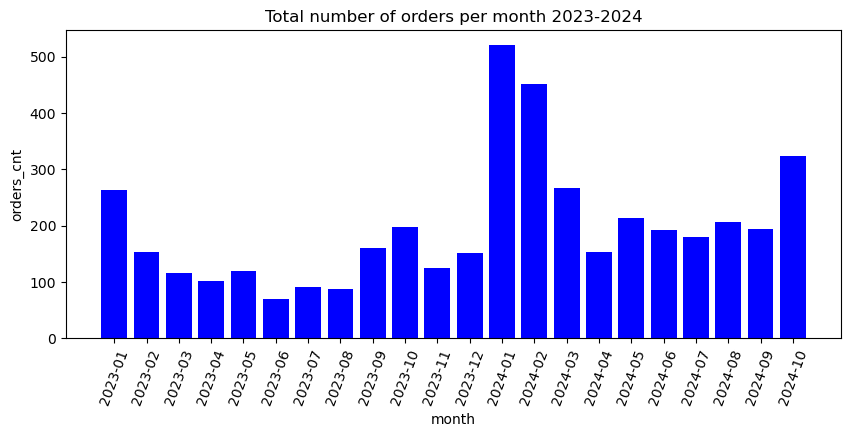

In [281]:
# отображу последние 2 года
orders_per_month = orders_per_month[orders_per_month['month'] >= '2023-01-01']

plt.figure(figsize = (10,4))
plt.title('Total number of orders per month 2023-2024')
plt.bar(orders_per_month['month'].dt.strftime('%Y-%m'), orders_per_month['afisha_n_orders'], color = 'b')
plt.xlabel('month')
plt.xticks(rotation=70)
plt.ylabel('orders_cnt')

plt.show()

Нельзя сказать, что использование сервиса "Афиша" плавно растет, количество не увеличивается плавно. Сравним похожим образом средний чек

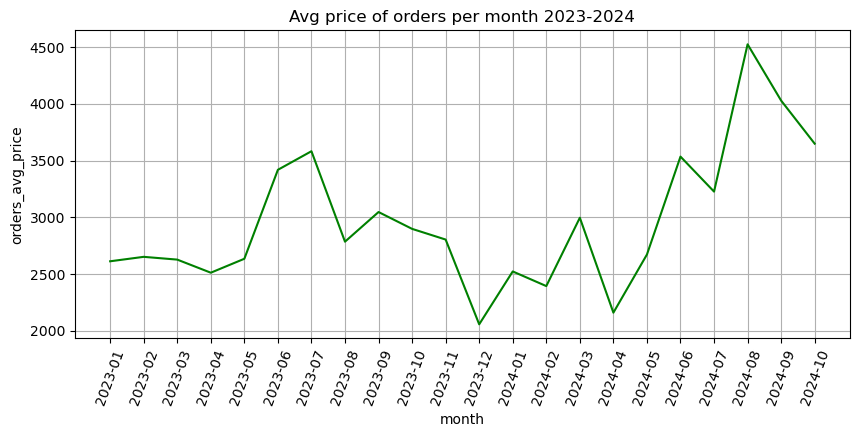

In [291]:
avg_price_per_month = afisha.groupby('month')['afisha_avg_price'].mean().reset_index()

avg_price_per_month = avg_price_per_month[avg_price_per_month['month'] >= '2023-01-01']

plt.figure(figsize = (10,4))
plt.title('Avg price of orders per month 2023-2024')
plt.plot(avg_price_per_month['month'].dt.strftime('%Y-%m'), avg_price_per_month['afisha_avg_price'], color = 'g')
plt.grid()
plt.xlabel('month')
plt.xticks(rotation=70)
plt.ylabel('orders_avg_price')

plt.show()

Заметно, что за последние месяцы средняя цена увеличилась. Значит даже если клиенты пользуются сервисом реже, каждая их покупка дороже

## Проверим еще один показатель: как меняется средняя цена покупки, если клиент много пользуется сервисом
### Для этого нужно разделить клиентов на примерные группы в зависимости от afisha_n_orders и сравнить afisha_avg_price

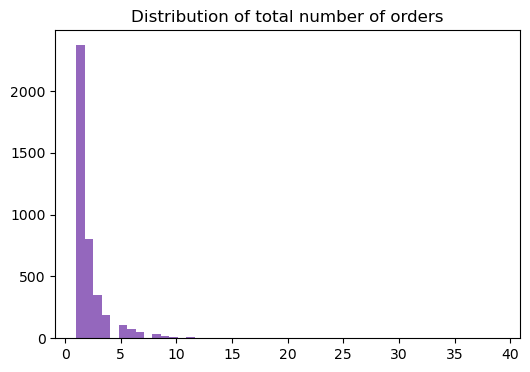

In [285]:
plt.figure(figsize=(6,4))
plt.title('Distribution of total number of orders')
plt.hist(afisha['afisha_n_orders'], bins = 50, color = 'tab:purple')
plt.show()

Разделим клиентов на группы в зависимости от количества покупок:
* __1-5__ покупок
* __6-10__ покупок
* __>10__ покупок

In [287]:
afisha_groups = afisha.copy()

afisha_groups.loc[(afisha_groups.afisha_n_orders > 0) & (afisha_groups.afisha_n_orders < 6), 'Orders group'] = '1-5'
afisha_groups.loc[(afisha_groups.afisha_n_orders >= 6) & (afisha_groups.afisha_n_orders < 11), 'Orders group'] = '6-10'
afisha_groups.loc[afisha_groups.afisha_n_orders >= 11, 'Orders group'] = '>10'


afisha_groups = afisha_groups.groupby('Orders group')['afisha_avg_price'].mean().reset_index()

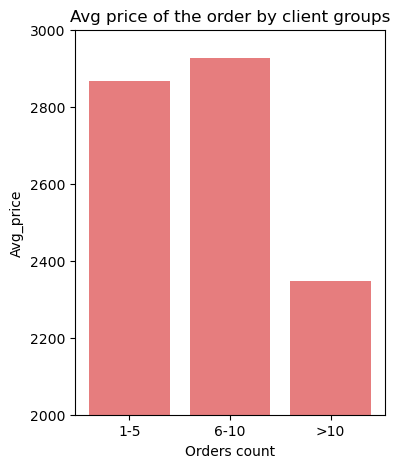

In [289]:
plt.figure(figsize=(4, 5))

plt.bar(afisha_groups['Orders group'], afisha_groups['afisha_avg_price'], color = 'tab:red', alpha = 0.6)
plt.ylim(2000, 3000)
plt.title('Avg price of the order by client groups')
plt.xlabel('Orders count')
plt.ylabel('Avg_price')

plt.show()

## Видно, что тенденции на увеличение средней цены нет
### Поэтому можно предложить нацелиться на клиентов, которые совершают много покупок в сервисе "Афиша"

Рассчеты для оценки рынка

In [305]:
df = pd.read_csv('city_clients.csv')

In [307]:
df = df[df['afisha_gmv'] > 0]

In [313]:
print('Оборот в сервисе «Афиша» с 01.01.2024:', df['afisha_gmv'].sum())

Оборот в сервисе «Афиша» с 01.01.2024: 617624527.5
